# Pre-process axisymmetric JAM correction for selected lenses

In this notebook, we read in the axisymmetric JAM correction $\sigma_\mathrm{axi}/\sigma_\mathrm{sph}$, condition the correction factors on the observed axis ratio of the stellar light, and interpolate the correction factor along the radial dimension at $R_\mathrm{slit}/R_\mathrm{eff}$. Here $R_\mathrm{slit}$ is the effective slit radius, and $R_\mathrm{eff}$ is the effective radius of the lens light. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import pandas as pd
import pickle
from lenstronomy.Analysis.light_profile import LightProfileAnalysis
from lenstronomy.LightModel.light_model import LightModel

import csv
import os
import yaml

from scipy.interpolate import interp1d
import copy
import random
import h5py

## SL2S lens sample

The SL2S lens models are from [Project Dinos 2](https://ui.adsabs.harvard.edu/abs/2024arXiv240810316S/abstract) . 

In [2]:
sl2s_dinos2 = pd.read_csv("../ExternalLenses/SL2S/sl2s_all_params_ws.csv")
sl2s_dinos2

,sid,name,flag_modelled,slit,width,seeing,z_lens,z_source,sigma_v,sigma_v_error,...,r_sersic_2_error_F475X,n_sersic_2_F475X,amp_sersic_2_F475X,amp_sersic_2_error_F475X,lensing_information,sigma_v_pritom,sigma_v_error_pritom,snr_pritom,instrument_resolution_pritom,instrument_resolution_err_pritom
0,1,SL2SJ0205-0930,1,0.9,1.60,1.1,0.557,1.33,276,37,...,0.011432,1.0,9.487270,1.054071,190.027178,NaN,NaN,NaN,NaN,NaN
1,2,SL2SJ0212-0555,1,0.9,1.60,0.7,0.750,2.74,273,22,...,NaN,NaN,NaN,NaN,172.687595,256.0,11.0,15.0,32.0,2.0
2,3,SL2SJ0214-0405,1,1.0,1.88,0.8,0.609,1.88,287,47,...,NaN,NaN,NaN,NaN,130.816504,209.0,10.0,23.0,32.0,2.0
3,4,SL2SJ0217-0513,1,1.5,1.68,0.6,0.646,1.85,239,27,...,0.026227,1.0,3.622641,0.649221,327.973970,273.0,26.0,9.0,97.0,8.0
4,5,SL2SJ0218-0802,1,0.9,1.60,1.0,0.884,2.06,246,48,...,0.023967,1.0,3.126669,0.261365,263.373114,254.0,28.0,5.0,31.0,2.0
5,6,SL2SJ0219-0829,1,1.0,1.68,0.7,0.389,2.15,289,23,...,NaN,NaN,NaN,NaN,128.502515,285.0,10.0,17.0,99.0,4.0
6,7,SL2SJ0220-0949,1,1.0,1.90,0.8,0.572,2.61,254,29,...,0.018049,1.0,3.840167,0.355203,256.280454,187.0,16.0,8.0,32.0,2.0
7,8,SL2SJ0226-0420,1,1.0,1.62,0.6,0.494,1.23,263,24,...,NaN,NaN,NaN,NaN,224.113923,310.0,14.0,20.0,94.0,6.0
8,9,SL2SJ0232-0408,1,1.0,1.68,0.7,0.352,2.34,281,26,...,NaN,NaN,NaN,NaN,179.173948,208.0,5.0,35.0,30.0,1.0
9,10,SL2SJ0233-0438,0,0.9,1.60,0.9,0.671,1.87,204,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Read in R_eff, q_light and slit radius 

The effective radius and axis ratio of lens light are pre-processed and stored in python dictionaries which are required as input by the [hierArc](https://github.com/sibirrer/hierArc) package. The effective slit radii are calcualted from the slit length $L_\mathrm{slit}$ and the slit width $W_\mathrm{slit}$ using: 
$$ 
R_\mathrm{slit} = \sqrt{L_\mathrm{slit} W_\mathrm{slit} / \pi },
$$
i.e. the radius of a circular aperture with the same area as the original rectangle one.

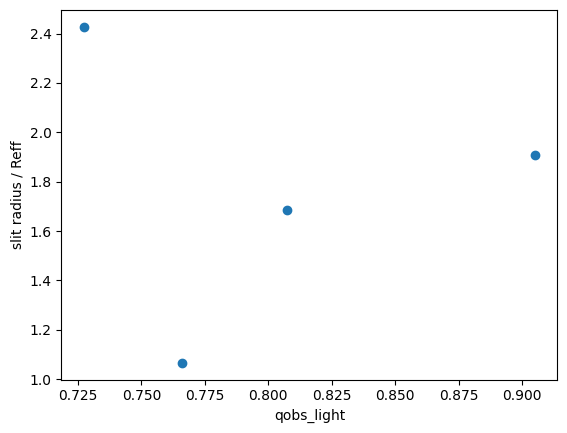

In [3]:
selected_sl2s = ['SL2SJ0226-0420', 'SL2SJ0855-0147', 'SL2SJ0904-0059', 'SL2SJ2221+0115']
sl2s_dinos2_name = sl2s_dinos2["name"].values

sl2s_dinos2_slit_radius = []
for name in selected_sl2s:
    idx = np.where(sl2s_dinos2_name == name)[0][0]
    slit_width = sl2s_dinos2["width"].values[idx]
    slit_length = sl2s_dinos2["slit"].values[idx]
    slit_radius = np.sqrt(slit_width * slit_length / np.pi)
    sl2s_dinos2_slit_radius.append(slit_radius)

sl2s_dinos2_slit_radius = np.array(sl2s_dinos2_slit_radius)

sl2s_likelihood = pd.read_pickle("../ExternalLenses/SL2S/sl2s_const_processed_all.pkl")
reff_dinos2 = []
qobs_dinos2 = []
for name in selected_sl2s:
    likelihood = [x for x in sl2s_likelihood if x["name"] == name][0]
    reff_dinos2.append(likelihood["kwargs_lens_properties"]["r_eff"])
    qobs_dinos2.append(likelihood["kwargs_lens_properties"]["q_light"])

reff_dinos2 = np.array(reff_dinos2)
qobs_dinos2 = np.array(qobs_dinos2)
sl2s_r_scale = sl2s_dinos2_slit_radius / reff_dinos2

plt.figure()
plt.scatter(qobs_dinos2, sl2s_r_scale)
plt.ylabel("slit radius / Reff")
plt.xlabel("qobs_light")
plt.show()

### Load correction file

In [4]:
with open("./correction_beta0_oblate_aperture.pickle", "rb") as f:
    correction_oblate_aperture = pickle.load(f)
    print(correction_oblate_aperture.keys())
with open("./correction_beta0_prolate_aperture.pickle", "rb") as f:
    correction_prolate_aperture = pickle.load(f)

correction_prolate_aperture["qobs"] = 1 / correction_prolate_aperture["qobs"]

dict_keys(['sigma_e_axi', 'sigma_e_sph', 'inc', 'qintr', 'qobs', 'reff', 'reff_sph', 'r_scale'])


#### Read in correction conditioned at q_light, and interpolate at slit radius/Reff

In [5]:
# get correction at qobs


def CorrectionCondQobs(qobs_lens, correction_dict):
    """read the correction factor conditioned on qobs

    Args:
        qobs_lens (_type_): _description_

    Returns:
        _type_: _description_
    """
    qobs_count, qobs_bin_edges = np.histogram(correction_dict["qobs"], bins=30, range=(0, 1.0 + 1e-5))
    ind_qobs_bin = np.digitize(qobs_lens, qobs_bin_edges) - 1

    qobs_lower_lim, qobs_upper_lim = (
        qobs_bin_edges[ind_qobs_bin],
        qobs_bin_edges[ind_qobs_bin + 1],
    )

    mask_select = (correction_dict["qobs"] <= qobs_upper_lim) & (correction_dict["qobs"] > qobs_lower_lim)
    sigma_e_sph_select = [correction_dict["sigma_e_sph"][i] for i in range(len(mask_select)) if mask_select[i]]
    sigma_e_axi_select = [correction_dict["sigma_e_axi"][i] for i in range(len(mask_select)) if mask_select[i]]
    correction_select = [x / y for x, y in zip(sigma_e_axi_select, sigma_e_sph_select)]

    return correction_select


def CorrectionInterpSlitRadius(correction_dict, qobs_lens, r_scale_lens):
    """interpolate the correction factor at slit_radius/Reff

    Args:
        qobs_lens (_type_): _description_
        slit_radius (_type_): _description_
        reff (_type_): _description_

    Returns:
        _type_: _description_
    """
    correction_sample = CorrectionCondQobs(qobs_lens, correction_dict)

    correction_dict_copy = copy.deepcopy(correction_dict)

    r_scale = correction_dict_copy["r_scale"]

    correction_interp_all = []

    for correction in correction_sample:
        nan_mask = np.isfinite(correction)
        correction = correction[nan_mask]
        r_scale_copy = copy.deepcopy(r_scale)
        r_scale_copy = r_scale_copy[nan_mask]

        extrapolate_function = interp1d(
            r_scale_copy, correction, fill_value="extrapolate"
        )  # Note: the correction factor at very small radius (~0.1 Reff) is calculated with extrapolation
        correction_interp = extrapolate_function(r_scale_lens)

        correction_interp_all.append(correction_interp)

    return correction_interp_all


def CorrectionConfiguration(name_list, qobs_lens, r_scale_lens, correction_oblate_dict, correction_prolate_dict):
    """save correction factor to a dictionary

    Args:
        name_list (_type_): _description_
        qobs_lens (_type_): _description_
        r_scale_lens (_type_): _description_

    Returns:
        _type_: _description_
    """
    assert len(name_list) == len(qobs_lens) == len(r_scale_lens), "all input should have the same length"

    correction_oblate_dict_copy = copy.deepcopy(correction_oblate_dict)
    correction_prolate_dict_copy = copy.deepcopy(correction_prolate_dict)

    dict_all = []

    for i, qobs in enumerate(qobs_lens):
        correction_oblate = CorrectionInterpSlitRadius(correction_oblate_dict_copy, qobs, r_scale_lens[i])
        correction_prolate = CorrectionInterpSlitRadius(correction_prolate_dict_copy, qobs, r_scale_lens[i])

        dict_all.append(
            {
                "name": name_list[i],
                "qobs": qobs,
                "r_scale": r_scale_lens[i],
                "correction_oblate": correction_oblate,
                "correction_prolate": correction_prolate,
            }
        )

    return dict_all

In [6]:
sl2s_correction = CorrectionConfiguration(
    selected_sl2s,
    qobs_dinos2,
    sl2s_r_scale,
    correction_oblate_aperture,
    correction_prolate_aperture,
)

## TDCOSMO sample with aperture kinematics

2 TDCOSMO lenses with MUSE aperture kinematic measurement. 

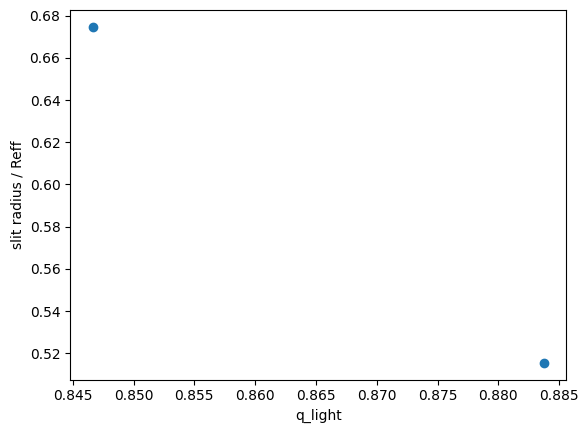

In [7]:
with open("../TDCOSMO_sample/tdcosmo_sample.yaml") as f:
    tdcosmo_dict = yaml.safe_load(f)

tdcosmo_likelihood = pd.read_pickle("../TDCOSMO_sample/tdcosmo7_likelihood_processed_const_.pkl")


tdcosmo_name_muse = ["DES0408-5354", "WGD2038-4008"]
tdcosmo_reff_muse = []
tdcosmo_qobs_muse = []

for name in tdcosmo_name_muse:
    reff = [x["kwargs_lens_properties"]["r_eff"] for x in tdcosmo_likelihood if x["name"] == name][0]
    tdcosmo_reff_muse.append(reff)

    qobs = [x["kwargs_lens_properties"]["q_light"] for x in tdcosmo_likelihood if x["name"] == name][0]
    if name == "WGD2038-4008":
        qobs = 0.8466387254212192 # calculated from triple sersic profile, see ../TDCOSMO_sample/tdcosmo_sample.yaml  
    tdcosmo_qobs_muse.append(qobs)

tdcosmo_reff_muse = np.array(tdcosmo_reff_muse)
tdcosmo_qobs_muse = np.array(tdcosmo_qobs_muse)

assert len(tdcosmo_name_muse) == len(tdcosmo_reff_muse) == len(tdcosmo_qobs_muse), "every lens should have reff and q_light"

tdcosmo_slit_radius_muse = np.array([tdcosmo_dict[name]["MUSE"]["aperture_radius"] for name in tdcosmo_name_muse])

tdcosmo_r_scale_muse = tdcosmo_slit_radius_muse / tdcosmo_reff_muse


plt.plot(tdcosmo_qobs_muse, tdcosmo_r_scale_muse, ls="", marker="o", label="TDCOSMO")
plt.xlabel("q_light")
plt.ylabel("slit radius / Reff")
plt.show()

TDCOSMO lenses with NIRSpec aperture kinematics


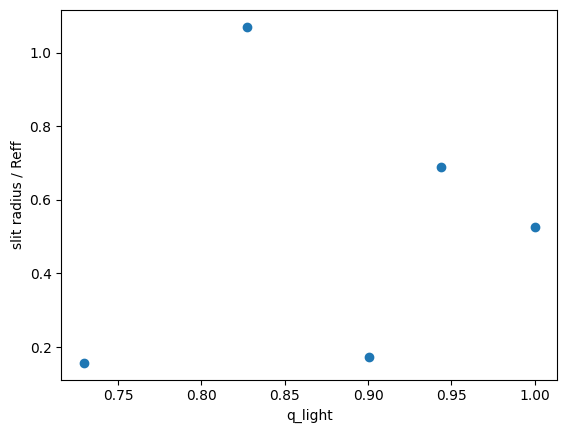

In [8]:
tdcosmo_name_jwst = ['B1608+656', 'HE0435-1223', 'SDSS1206+4332', 'WFI2033-4723', 'PG1115+080']
tdcosmo_reff_jwst = np.array([tdcosmo_dict[name]["r_eff"] for name in tdcosmo_name_jwst])

tdcosmo_qobs_jwst = []

for name in tdcosmo_name_jwst:
    likelihood = [x for x in tdcosmo_likelihood if x["name"] == name][0]
    tdcosmo_qobs_jwst.append(likelihood["kwargs_lens_properties"]["q_light"])

tdcosmo_slit_radius_jwst = [np.sqrt(0.55**2/np.pi) for i in range(len(tdcosmo_name_jwst))] 

tdcosmo_r_scale_jwst = tdcosmo_slit_radius_jwst / tdcosmo_reff_jwst


plt.plot(tdcosmo_qobs_jwst, tdcosmo_r_scale_jwst, ls="", marker="o", label="TDCOSMO")
plt.xlabel("q_light")
plt.ylabel("slit radius / Reff")
plt.show()

### Read in correction

In [9]:
tdcosmo_name = tdcosmo_name_muse + tdcosmo_name_jwst
tdcosmo_qobs = np.concatenate([tdcosmo_qobs_muse, tdcosmo_qobs_jwst])
tdcosmo_r_scale = np.concatenate([tdcosmo_r_scale_muse, tdcosmo_r_scale_jwst])

tdcosmo_correction = CorrectionConfiguration(
    tdcosmo_name,
    tdcosmo_qobs,
    tdcosmo_r_scale,
    correction_oblate_aperture,
    correction_prolate_aperture,
)

## SLACS KCWI radial bins

In [10]:
selected_kcwi = ['SDSSJ0029-0055', 'SDSSJ0037-0942', 'SDSSJ1112+0826', 'SDSSJ1204+0358', 'SDSSJ1250+0523', 'SDSSJ1306+0600', 'SDSSJ1402+6321', 'SDSSJ1531-0105', 'SDSSJ1621+3931', 'SDSSJ1627-0053', 'SDSSJ1630+4520']

kwci_likelihood = pd.read_pickle("../ExternalLenses/SLACS/slacs_kcwi_const_processed.pkl")

kcwi_qobs = []
kcwi_reff = []

for name in selected_kcwi:
    likelihood = [x for x in kwci_likelihood if x["name"] == name][0]
    kcwi_qobs.append(likelihood["kwargs_lens_properties"]["q_light"])
    kcwi_reff.append(likelihood["kwargs_lens_properties"]["r_eff"])

kcwi_qobs = np.array(kcwi_qobs)
kcwi_reff = np.array(kcwi_reff)

# access IFU measurement (for the radial bins)
ifu_path = "../ExternalLenses/SLACS/slacs_kcwi_data"


def load_ifu_bin_center(name):
    ifu_file = os.path.join(ifu_path, name, str(name + "_kinmap.csv"))
    r_outer = []
    r_inner = []
    with open(ifu_file, newline="") as myFile:
        reader = csv.DictReader(myFile)
        for i, row in enumerate(reader):
            r_outer.append(float(row["bin_outer_edge"]))
            r_inner.append(float(row["bin_inner_edge"]))
    r_bins = np.append(r_inner, r_outer[-1])
    return (r_bins[1:] + r_bins[:-1]) / 2.0


kcwi_radial_bins = []
for name in selected_kcwi:
    radial_bins = load_ifu_bin_center(name)
    kcwi_radial_bins.append(radial_bins)

kcwi_r_scale = [x / kcwi_reff[i] for i, x in enumerate(kcwi_radial_bins)]

### read in correction 

In [11]:
with open("./correction_beta0_oblate_annuli.pickle", "rb") as f:
    correction_oblate_annuli = pickle.load(f)
    print(correction_oblate_annuli.keys())
with open("./correction_beta0_prolate_annuli.pickle", "rb") as f:
    correction_prolate_annuli = pickle.load(f)

correction_prolate_annuli["qobs"] = 1 / correction_prolate_annuli["qobs"]

# convert the scaled radial bin edges to radial bin centers
correction_oblate_annuli["r_scale"] = (
    correction_oblate_annuli["r_scale"][:-1] + correction_oblate_annuli["r_scale"][1:]
) / 2.0
correction_prolate_annuli["r_scale"] = (
    correction_prolate_annuli["r_scale"][:-1] + correction_prolate_annuli["r_scale"][1:]
) / 2.0

dict_keys(['sigma_e_axi', 'sigma_e_sph', 'inc', 'qintr', 'qobs', 'reff', 'reff_sph', 'r_scale'])


In [12]:
kcwi_correction = CorrectionConfiguration(
    selected_kcwi,
    kcwi_qobs,
    kcwi_r_scale,
    correction_oblate_annuli,
    correction_prolate_annuli,
)

## RXJ1131-1231

This lens has IFU datafrom KCWI and from JWST Nirspec

In [13]:
ifu_kin_kcwi_file = "../TDCOSMO_sample/TDCOSMO_data/RXJ1131-1231/rxj1131_kcwi_v_rms_binned.h5"
ifu_kin_jwst_file = "../TDCOSMO_sample/TDCOSMO_data/RXJ1131-1231/rxj1131_jwst_v_rms_binned.h5"


with h5py.File(ifu_kin_kcwi_file, "r") as f:
    radial_bins_kcwi = f["radial_bins"][()]
radial_bins_kcwi = (radial_bins_kcwi[1:] + radial_bins_kcwi[:-1]) / 2.0


with h5py.File(ifu_kin_jwst_file, "r") as f:
    radial_bins_jwst = f["radial_bins"][()]
radial_bins_jwst = (radial_bins_jwst[1:] + radial_bins_jwst[:-1]) / 2.0

reff_1131 = [x["kwargs_lens_properties"]["r_eff"] for x in tdcosmo_likelihood if x["name"] == "RXJ1131-1231"][0]
qobs_1131 = [x["kwargs_lens_properties"]["q_light"] for x in tdcosmo_likelihood if x["name"] == "RXJ1131-1231"][0]

r_scale_1131_kcwi = radial_bins_kcwi / reff_1131
r_scale_1131_kcwi = np.array(r_scale_1131_kcwi)

r_scale_1131_jwst = radial_bins_jwst / reff_1131
r_scale_1131_jwst = np.array(r_scale_1131_jwst)

r_scale_1131 = np.concatenate([r_scale_1131_kcwi, r_scale_1131_jwst])

rxj1131_correction = CorrectionConfiguration(
    ["RXJ1131-1231"],
    [qobs_1131],
    [r_scale_1131],
    correction_oblate_annuli,
    correction_prolate_annuli,
)

tdcosmo_correction += rxj1131_correction

## Combine the correction using the oblate and prolate fraction

Misalignment angle measured in K24:

In [14]:
obj_names = [
    "SDSSJ0029-0055",
    "SDSSJ0037-0942",
    "SDSSJ0330-0020",
    "SDSSJ1112+0826",
    "SDSSJ1204+0358",
    "SDSSJ1250+0523",
    "SDSSJ1306+0600",
    "SDSSJ1402+6321",
    "SDSSJ1531-0105",
    "SDSSJ1538+5817",
    "SDSSJ1621+3931",
    "SDSSJ1627-0053",
    "SDSSJ1630+4520",
    "SDSSJ2303+1422",
]

misalignment = np.array([31.0, 28.0, 34.0, 3.0, 14.0, 71.0, 35.0, 19.0, 9.0, 19.0, 9.0, 14.0, 5.0, 12.0])

misalignment_err = np.array([30.0, 4.0, 10.0, 3.0, 11.0, 7.0, 13.0, 8.0, 30.0, 30.0, 4.0, 13.0, 9.0, 30.0])

In the following we calculate the likelihood of the data as a function of f, where f is the fraction of oblates and 1-f is the fraction of prolates. 

The likelihood function can be written as: 

\begin{equation}
L(\Delta \phi_i \vert f) = \frac{1}{\sqrt{2\pi\sigma^2}} \cdot [f  \exp(-\frac{\Delta \phi_i^2}{2\sigma^2}) + (1 - f) \exp(-\frac{(\Delta \phi_i - 90)^2}{2\sigma^2})],
\end{equation}
for an individual data point.

In [15]:
# use one data point as an example


def LikelihoodIndividual(misalignment, misalignment_err, f_array):
    likelihood_array = np.full_like(f_array, np.nan)
    for i, f in enumerate(f_array):
        likelihood_array[i] = (
            f * np.exp(-(misalignment**2) / 2 / misalignment_err**2)
            + (1 - f) * np.exp(-((misalignment - 90) ** 2) / 2 / misalignment_err**2)
        ) / np.sqrt(2 * np.pi * misalignment_err**2)
    norm = np.trapz(likelihood_array, f_array)
    likelihood_array = likelihood_array / norm
    return likelihood_array

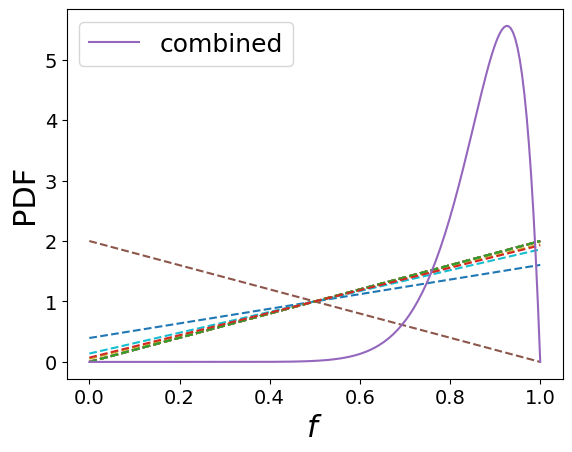

In [16]:
f_array = np.linspace(0, 1, 200)
likelihood_all = []
for i in range(len(misalignment)):
    likelihood_individual = LikelihoodIndividual(misalignment[i], misalignment_err[i], f_array)
    likelihood_all.append(likelihood_individual)
    plt.plot(f_array, likelihood_individual, ls="--")

likelihood_all = np.array(likelihood_all)
likelihood_combined = np.prod(likelihood_all, axis=0)
norm = np.trapz(likelihood_combined, f_array)
likelihood_combined = likelihood_combined / norm
# plt.axhline(0, ls = ':')
plt.plot(f_array, likelihood_combined, label="combined")
plt.xlabel("$f$", size=22)
plt.ylabel("PDF", size=22)
plt.xticks(size=14)
plt.yticks(size=14)
plt.legend(prop={"size": 18})
plt.show()


def DrawFromPDF(x_pdf, y_pdf, num):
    cdf = np.cumsum(y_pdf) / np.cumsum(y_pdf)[-1]
    inv_cdf = interp1d(x=cdf, y=x_pdf, fill_value="extrapolate")
    random_num = np.random.uniform(0, 1, num)
    var_rm = inv_cdf(random_num)

    return var_rm


f_draw = DrawFromPDF(f_array, likelihood_combined, 200)
f_draw = np.sort(f_draw)

In [17]:
def PickFromList(lst, num):
    return [random.choice(lst) for _ in range(num)]


def CombineCorrection_with_Single_f(correction_oblate, correction_prolate, f):
    """combine the oblate and prolate correction using a single-valued f

    Args:
        correction_oblate (_type_): _description_
        correction_prolate (_type_): _description_
        f (_type_): _description_

    Returns:
        _type_: _description_
    """
    if len(correction_prolate) != 0:
        num_pick_oblate = round(f * (len(correction_oblate) + len(correction_prolate)))
        num_pick_prolate = len(correction_oblate) + len(correction_prolate) - num_pick_oblate
    else:
        num_pick_oblate = len(correction_oblate) + len(correction_prolate)
        num_pick_prolate = 0

    oblate_pick = PickFromList(correction_oblate, num_pick_oblate)
    prolate_pick = PickFromList(correction_prolate, num_pick_prolate)
    combined_pick = oblate_pick + prolate_pick

    return combined_pick


def CombineCorrection_with_f_array(correction_oblate, correction_prolate, f_array):
    """combine the corrections by marginalizing over f

    Args:
        correction_oblate (_type_): _description_
        correction_prolate (_type_): _description_
        f_array (_type_): _description_

    Returns:
        _type_: _description_
    """
    correction_all = []

    for f in f_array:
        correction_combined = CombineCorrection_with_Single_f(correction_oblate, correction_prolate, f)
        correction_all += correction_combined

    return correction_all

### Combine the correction for all the lens sets

In [18]:
def CombineCorrection4Sample(correction_dict, f_draw):
    """Combine the correction of oblate and prolate population by margianlizing the oblate fraction inferred from IFU data of SLACS lenses

    Args:
        correction_dict (_type_): _description_
        f_draw (_type_): _description_

    Returns:
        _type_: _description_
    """
    correction_dict_new = copy.deepcopy(correction_dict)
    for i, item in enumerate(correction_dict_new):
        correction_oblate = item["correction_oblate"]
        correction_prolate = item["correction_prolate"]

        correction_combined = CombineCorrection_with_f_array(correction_oblate, correction_prolate, f_draw)
        correction_dict_new[i]["correction_combined"] = correction_combined
    return correction_dict_new

In [19]:
sl2s_correction = CombineCorrection4Sample(sl2s_correction, f_draw)
kcwi_correction = CombineCorrection4Sample(kcwi_correction, f_draw)
tdcosmo_correction = CombineCorrection4Sample(tdcosmo_correction, f_draw)

# adjust the format of the correction for samples with aperture data
for item in sl2s_correction:
    item["correction_combined"] = np.array(item["correction_combined"])
    item["correction_oblate"] = np.array(item["correction_oblate"])
    item["correction_prolate"] = np.array(item["correction_prolate"])

for correction in tdcosmo_correction:
    if correction["name"] != "RXJ1131-1231":
        correction["correction_combined"] = np.array(correction["correction_combined"])
        correction["correction_oblate"] = np.array(correction["correction_oblate"])
        correction["correction_prolate"] = np.array(correction["correction_prolate"])

update_file_sl2s = False
update_file_kcwi = False
update_file_tdcosmo = True


if update_file_sl2s:
    with open("./sl2s_correction.pickle", "wb") as f:
        pickle.dump(sl2s_correction, f)

if update_file_kcwi:
    with open("./kcwi_correction.pickle", "wb") as f:
        pickle.dump(kcwi_correction, f)

if update_file_tdcosmo:
    with open("./tdcosmo_correction.pickle", "wb") as f:
        pickle.dump(tdcosmo_correction, f)